# Four Qubit Chip Design

In [12]:
%reload_ext autoreload
%autoreload 2

## Prerequisite

In [13]:
import os
import numpy as np
import pandas as pd
from collections import OrderedDict

from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, Headings

from qiskit_metal.qlibrary.qubits.transmon_pocket_cl import TransmonPocketCL
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.anchored_path import RouteAnchors
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.terminations.launchpad_wb_coupled import LaunchpadWirebondCoupled

## Four Qubit Design

We will aim for the following parameters on our chip;

- qubit frequency => 4.8, 5, 5.2, 5.4 GHz
- qubit anharmonicity => 300 MHz
- qubit-bus coupling ($g_{q - bus}$) => 80 MHz
- qubit-readout ($\chi_{qc}$ ) => 1 MHz
- bus frequency 
    - Q1 (bus_12, bus_14) => 5.8, 6.0 GHz
    - Q2 (bus_23, bus_12) => 6.2, 5.8 GHz
    - Q3 (bus_34, bus_23) => 6.4, 6.2 GHz
    - Q4 (bus_14, bus_34) => 6.0, 6.4 GHz
- readout frequencies => 6.8, 7, 7.2, 7.4 GHz
- readout Q_external => 2000 ????

In [14]:
design = designs.DesignPlanar()

gui = MetalGUI(design)

In [15]:
design.overwrite_enabled = True

In [16]:
design.variables['cpw_width'] = '10 um'
design.variables['cpw_gap'] = '6 um'
design._chips['main']['size']['size_x'] = '9mm'
design._chips['main']['size']['size_y'] = '6.5mm'

We need 4 transmons with 3 connection pads each and a chargeline. Let's explore the options of one transmon

In [17]:
TransmonPocketCL.get_template_options(design)

{'pos_x': '0.0um',
 'pos_y': '0.0um',
 'orientation': '0.0',
 'chip': 'main',
 'layer': '1',
 'connection_pads': {},
 '_default_connection_pads': {'pad_gap': '15um',
  'pad_width': '125um',
  'pad_height': '30um',
  'pad_cpw_shift': '5um',
  'pad_cpw_extent': '25um',
  'cpw_width': 'cpw_width',
  'cpw_gap': 'cpw_gap',
  'cpw_extend': '100um',
  'pocket_extent': '5um',
  'pocket_rise': '65um',
  'loc_W': '+1',
  'loc_H': '+1'},
 'pad_gap': '30um',
 'inductor_width': '20um',
 'pad_width': '455um',
 'pad_height': '90um',
 'pocket_width': '650um',
 'pocket_height': '650um',
 'make_CL': True,
 'cl_gap': '6um',
 'cl_width': '10um',
 'cl_length': '20um',
 'cl_ground_gap': '6um',
 'cl_pocket_edge': '0',
 'cl_off_center': '50um',
 'hfss_wire_bonds': False,
 'q3d_wire_bonds': False,
 'aedt_q3d_wire_bonds': False,
 'aedt_hfss_wire_bonds': False,
 'hfss_inductance': '10nH',
 'hfss_capacitance': 0,
 'hfss_resistance': 0,
 'hfss_mesh_kw_jj': 7e-06,
 'q3d_inductance': '10nH',
 'q3d_capacitance': 0,
 

We want to change the `pad_width` for these transmons, as well as define the 3 connection pads and chargeline.

To apply the same modifications to all 4 transmons, we define a single option-dictionary to pass to all transmons at the monent of creation

In [18]:
offset_tm = 69  #we the transmon slightly out of center-line

q1 = TransmonPocketCL(design, 'Q1', options = dict(
    pos_x='-2420um', 
    pos_y=f'{offset_tm}um', 
    orientation = '180',
    gds_cell_name='FakeJunction_01',
    cl_off_center = '-50um',
    cl_pocket_edge = '180',
    connection_pads=dict(
        readout = dict(loc_W=+1, loc_H=-1, pad_width='70um', cpw_extend =  '50um'), 
        bus_12 = dict(loc_W=-1, loc_H=-1, pad_width='125um', cpw_extend = '50um'),
        bus_14 = dict(loc_W=-1, loc_H=+1, pad_width='110um', cpw_extend = '50um')
    )))
q2 = TransmonPocketCL(design, 'Q2', options = dict(
    pos_x='0um', 
    pos_y='+857.6um', 
    orientation = '90',
    gds_cell_name='FakeJunction_01',
    cl_off_center = '-50um',
    cl_pocket_edge = '180',
    connection_pads=dict(
        readout = dict(loc_W=+1, loc_H=-1, pad_width='70um', cpw_extend = '50um'), 
        bus_23 = dict(loc_W=-1, loc_H=-1, pad_width='125um', cpw_extend = '50um'),
        bus_12 = dict(loc_W=-1, loc_H=+1, pad_width='110um', cpw_extend = '50um')
    )))

q3 = TransmonPocketCL(design, 'Q3', options = dict(
    pos_x='+2420um', 
    pos_y=f'{offset_tm}um',
    gds_cell_name='FakeJunction_01',
    cl_off_center = '-50um',
    cl_pocket_edge = '180', 
    connection_pads=dict(
        readout = dict(loc_W=+1, loc_H=-1, pad_width='70um', cpw_extend = '50um'), 
        bus_34 = dict(loc_W=-1, loc_H=-1, pad_width='125um', cpw_extend = '50um'),
        bus_23 = dict(loc_W=-1, loc_H=+1, pad_width='110um', cpw_extend = '50um')
    )))

q4 = TransmonPocketCL(design, 'Q4', options = dict(
    pos_x='0um', 
    pos_y='-857.6um',
    orientation = '270', 
    gds_cell_name='FakeJunction_01',
    cl_off_center = '-50um',
    cl_pocket_edge = '180',
    connection_pads=dict(
        readout = dict(loc_W=+1, loc_H=-1, pad_width='70um', cpw_extend = '50um'), 
        bus_14 = dict(loc_W=-1, loc_H=-1, pad_width='125um', cpw_extend = '50um'),
        bus_34 = dict(loc_W=-1, loc_H=+1, pad_width='110um', cpw_extend = '50um')
    )))

gui.rebuild()
gui.autoscale()

We can now create the 4 transmons by specifying the desired coordinates and orientations.

Let's now connect the transmons with tranismission lines. We want to have an "exact length" transmission line, so we will use the `RouteMeander`. Let's first observe what are the default options

In [19]:
RouteMeander.get_template_options(design)

{'chip': 'main',
 'layer': '1',
 'pin_inputs': {'start_pin': {'component': '', 'pin': ''},
  'end_pin': {'component': '', 'pin': ''}},
 'fillet': '0',
 'lead': {'start_straight': '0mm',
  'end_straight': '0mm',
  'start_jogged_extension': '',
  'end_jogged_extension': ''},
 'total_length': '7mm',
 'trace_width': 'cpw_width',
 'meander': {'spacing': '200um', 'asymmetry': '0um'},
 'snap': 'true',
 'prevent_short_edges': 'true',
 'hfss_wire_bonds': False,
 'q3d_wire_bonds': False,
 'aedt_q3d_wire_bonds': False,
 'aedt_hfss_wire_bonds': False}

We want to globally override the default lead (straight initial segment leaving the transmon) and the default fillet (corner rounding radius). Let's collect this information in one dictionary

In [20]:
from qiskit_metal.analyses.em.cpw_calculations import guided_wavelength

def find_resonator_length(frequency, line_width, line_gap, N): 
    #frequency in GHz
    #line_width/line_gap in um
    #N -> 2 for lambda/2, 4 for lambda/4
    #substrate dimensions and properties already set
    
    [lambdaG, etfSqrt, q] = guided_wavelength(frequency*10**9, line_width*10**-6,
                                              line_gap*10**-6, 750*10**-6, 200*10**-9, 11.9)
    return str(lambdaG/N*10**3)+" mm"

In [21]:
q1.pins.keys()

dict_keys(['readout', 'bus_12', 'bus_14', 'Charge_Line'])

In [22]:
bus_12 = find_resonator_length(frequency=5.8, line_width=10, line_gap=6, N=2)
bus_14 = find_resonator_length(frequency=6.0, line_width=10, line_gap=6, N=2)
bus_23 = find_resonator_length(frequency=6.2, line_width=10, line_gap=6, N=2)
bus_34 = find_resonator_length(frequency=6.4, line_width=10, line_gap=6, N=2)

bus_12 = str(round(float(bus_12.split()[0]), 2)) + 'mm'
bus_14 = str(round(float(bus_14.split()[0]), 2)) + 'mm'
bus_23 = str(round(float(bus_23.split()[0]), 2)) + 'mm'
bus_34 = str(round(float(bus_34.split()[0]), 2)) + 'mm'

print('bus_12 length: ' + bus_12)
print('bus_14 length: ' + bus_14)
print('bus_23 length: ' + bus_23)
print('bus_34 length: ' + bus_34)

bus_12 length: 10.31mm
bus_14 length: 9.97mm
bus_23 length: 9.64mm
bus_34 length: 9.34mm


In [23]:
fillet='99.99um'
cpw_options = Dict(
    lead=Dict(
        start_straight='100um',
        end_straight='250um'),
    fillet=fillet
    )

We then want each transmission line to be connected to different pins and to have different lengths and asymmetry w.r.t their centerline. Let's collect this information in other dictionaries. Before doing that, to manage the dictionaries in a simpler way, we redefine the `RouteMeander` signature by wrapping it into a convenience method named `connect`

In [24]:
def connect(cpw_name: str, pin1_comp_name: str, pin1_comp_pin: str, pin2_comp_name: str, pin2_comp_pin: str,
            length: str, asymmetry='0 um'):
    """Connect two pins with a CPW."""
    myoptions = Dict(
        pin_inputs=Dict(
            start_pin=Dict(
                component=pin1_comp_name,
                pin=pin1_comp_pin),
            end_pin=Dict(
                component=pin2_comp_name,
                pin=pin2_comp_pin)),
        total_length=length)
    myoptions.update(cpw_options)
    myoptions.meander.asymmetry = asymmetry
    return RouteMeander(design, cpw_name, myoptions)

We can now proceed and define the meanders following the signature: `connect(cpw_name, pin1_comp_name, pin1_comp_pin, pin2_comp_name, pin2_comp_pin, length, asymmetry)`

In [25]:
asym = 500
cpw1 = connect('cpw1', 'Q1', 'bus_12', 'Q2', 'bus_12', bus_12, f'+{asym+0.75*offset_tm}um')
cpw2 = connect('cpw2', 'Q3', 'bus_23', 'Q2', 'bus_23', bus_23, f'-{asym+0.75*offset_tm}um')
cpw3 = connect('cpw3', 'Q3', 'bus_34', 'Q4', 'bus_34', bus_34, f'+{asym-1.25*offset_tm}um')
cpw4 = connect('cpw4', 'Q1', 'bus_14', 'Q4', 'bus_14', bus_14, f'-{asym-1.25*offset_tm}um')

gui.rebuild()
gui.autoscale()

### Let's now connect the core elements to the launchpads

First we setup the launchpad location and orientation

In [26]:
# V1 - Corners
launch_cl_q1 = LaunchpadWirebond(design, 'Launch_CL_Q1', options = dict(pos_x='-3545um', pos_y='-2812um', orientation='90', lead_length='0um'))
launch_cl_q2 = LaunchpadWirebond(design, 'Launch_CL_Q2', options = dict(pos_x='-3545um', pos_y='2812um', orientation='270', lead_length='0um'))
launch_cl_q3 = LaunchpadWirebond(design, 'Launch_CL_Q3', options = dict(pos_x='3545um', pos_y='2812um', orientation='270', lead_length='0um'))
launch_cl_q4 = LaunchpadWirebond(design, 'Launch_CL_Q4', options = dict(pos_x='3545um', pos_y='-2812um', orientation='90', lead_length='0um'))

# V2
launch_ro_q1 = LaunchpadWirebondCoupled(design, 'Launch_RO_Q1', options = dict(pos_x='-4020um', pos_y='0', orientation='0', lead_length='30um'))
launch_ro_q2 = LaunchpadWirebondCoupled(design, 'Launch_RO_Q2', options = dict(pos_x='990um', pos_y='2812um', orientation='270', lead_length='30um'))
launch_ro_q3 = LaunchpadWirebondCoupled(design, 'Launch_RO_Q3', options = dict(pos_x='4020um', pos_y='0', orientation='180', lead_length='30um'))
launch_ro_q4 = LaunchpadWirebondCoupled(design, 'Launch_RO_Q4', options = dict(pos_x='-990um', pos_y='-2812um', orientation='90', lead_length='30um'))

gui.rebuild()
gui.autoscale()

Then we route. First the V2 launchpads - Exchange Coupler Lines to Edges

Connected to the readout resonators of each qubit

Used for dispersive readout — you send a probe tone and measure the reflected/transmitted signal to determine the qubit state without directly measuring it

In [27]:
readout1 = find_resonator_length(frequency=6.8, line_width=10, line_gap=6, N=2)
readout2 = find_resonator_length(frequency=7.0, line_width=10, line_gap=6, N=2)
readout3 = find_resonator_length(frequency=7.2, line_width=10, line_gap=6, N=2)
readout4 = find_resonator_length(frequency=7.4, line_width=10, line_gap=6, N=2)

readout1 = str(round(float(readout1.split()[0]), 2)) + 'mm'
readout2 = str(round(float(readout2.split()[0]), 2)) + 'mm'
readout3 = str(round(float(readout3.split()[0]), 2)) + 'mm'
readout4 = str(round(float(readout4.split()[0]), 2)) + 'mm'

print('readout1 length: ' + readout1)
print('readout2 length: ' + readout2)
print('readout3 length: ' + readout3)
print('readout4 length: ' + readout4)

readout1 length: 8.79mm
readout2 length: 8.54mm
readout3 length: 8.31mm
readout4 length: 8.08mm


In [28]:
asym = 150
cpw_options = Dict(
    lead=Dict(
        start_straight='430um',
        end_straight='0um'),
    fillet=fillet
    )
readout1 = connect('Readout1', 'Q1', 'readout', 'Launch_RO_Q1', 'tie', readout1, f'+{asym}um')
readout3 = connect('Readout3', 'Q3', 'readout', 'Launch_RO_Q3', 'tie', readout3, f'+{asym}um')

asym = 200
cpw_options = Dict(
    lead=Dict(
        start_straight='535um',
        end_straight='0um'),
    fillet=fillet
    )
readout2 = connect('Readout2', 'Q2', 'readout', 'Launch_RO_Q2', 'tie', readout2, f'+{asym}um')
readout4 = connect('Readout4', 'Q4', 'readout', 'Launch_RO_Q4', 'tie', readout4, f'+{asym}um')

gui.rebuild()
gui.autoscale()

Finally we route the V1 launchpads - Charge Lines to Corners

We create the transmission lines between the corner launchpads and the open to grounds

Connected to the charge lines of each qubit

Used for single-qubit control — sending microwave pulses to drive qubit transitions

In [29]:
from collections import OrderedDict
jogsA_in = OrderedDict()
jogsA_in[0] = ["L", '200um']

options_charge_line1 = {'pin_inputs': 
            {'start_pin': {'component': 'Q1', 'pin': 'Charge_Line'}, 
             'end_pin': {'component': 'Launch_CL_Q1', 'pin': 'tie'}},
            'lead': {'start_straight': '120um', 'end_straight': '225um','start_jogged_extension': jogsA_in},
            'fillet': fillet
            }
charge_line1 = RouteAnchors(design, 'Charge_Line1', options_charge_line1)

options_charge_line3 = {'pin_inputs': 
            {'start_pin': {'component': 'Q3', 'pin': 'Charge_Line'}, 
             'end_pin': {'component': 'Launch_CL_Q3', 'pin': 'tie'}},
            'lead': {'start_straight': '120um', 'end_straight': '225um', 'start_jogged_extension': jogsA_in},
            'fillet': fillet
            }
charge_line3 = RouteAnchors(design, 'Charge_Line3', options_charge_line3)

gui.rebuild()
gui.autoscale()

In [30]:
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder

jogsB_in = OrderedDict()
jogsB_in[0] = ["L", '300um']

anchors2c = OrderedDict()
anchors2c[0] = np.array([-2, 2.5])

options_charge_line2 = {'pin_inputs': 
            {'start_pin': {'component': 'Q2', 'pin': 'Charge_Line'}, 
             'end_pin': {'component': 'Launch_CL_Q2', 'pin': 'tie'}},
            'lead': {'start_straight': '400um', 'end_straight': '100um',
                     'start_jogged_extension': jogsB_in},
            'anchors': anchors2c,
            'fillet': fillet
            }

charge_line2 = RouteAnchors(design, 'Charge_Line2', options_charge_line2)
# charge_line2 = RoutePathfinder(design, 'Charge_Line2', options_charge_line2)

anchors4c = OrderedDict()
anchors4c[0] = np.array([2, -2.5])

options_charge_line4 = {'pin_inputs': 
            {'start_pin': {'component': 'Q4', 'pin': 'Charge_Line'}, 
             'end_pin': {'component': 'Launch_CL_Q4', 'pin': 'tie'}},
            'lead': {'start_straight': '400um', 'end_straight': '225um',
                     'start_jogged_extension': jogsB_in},
            'anchors': anchors4c,
            'fillet': fillet
            }

charge_line4 = RouteAnchors(design, 'Charge_Line4', options_charge_line4)
# charge_line4 = RoutePathfinder(design, 'Charge_Line4', options_charge_line4)

gui.rebuild()
gui.autoscale()

In [31]:
# Get a list of all the qcomponents in QDesign and then zoom on them.
all_component_names = design.components.keys()

gui.zoom_on_components(all_component_names)

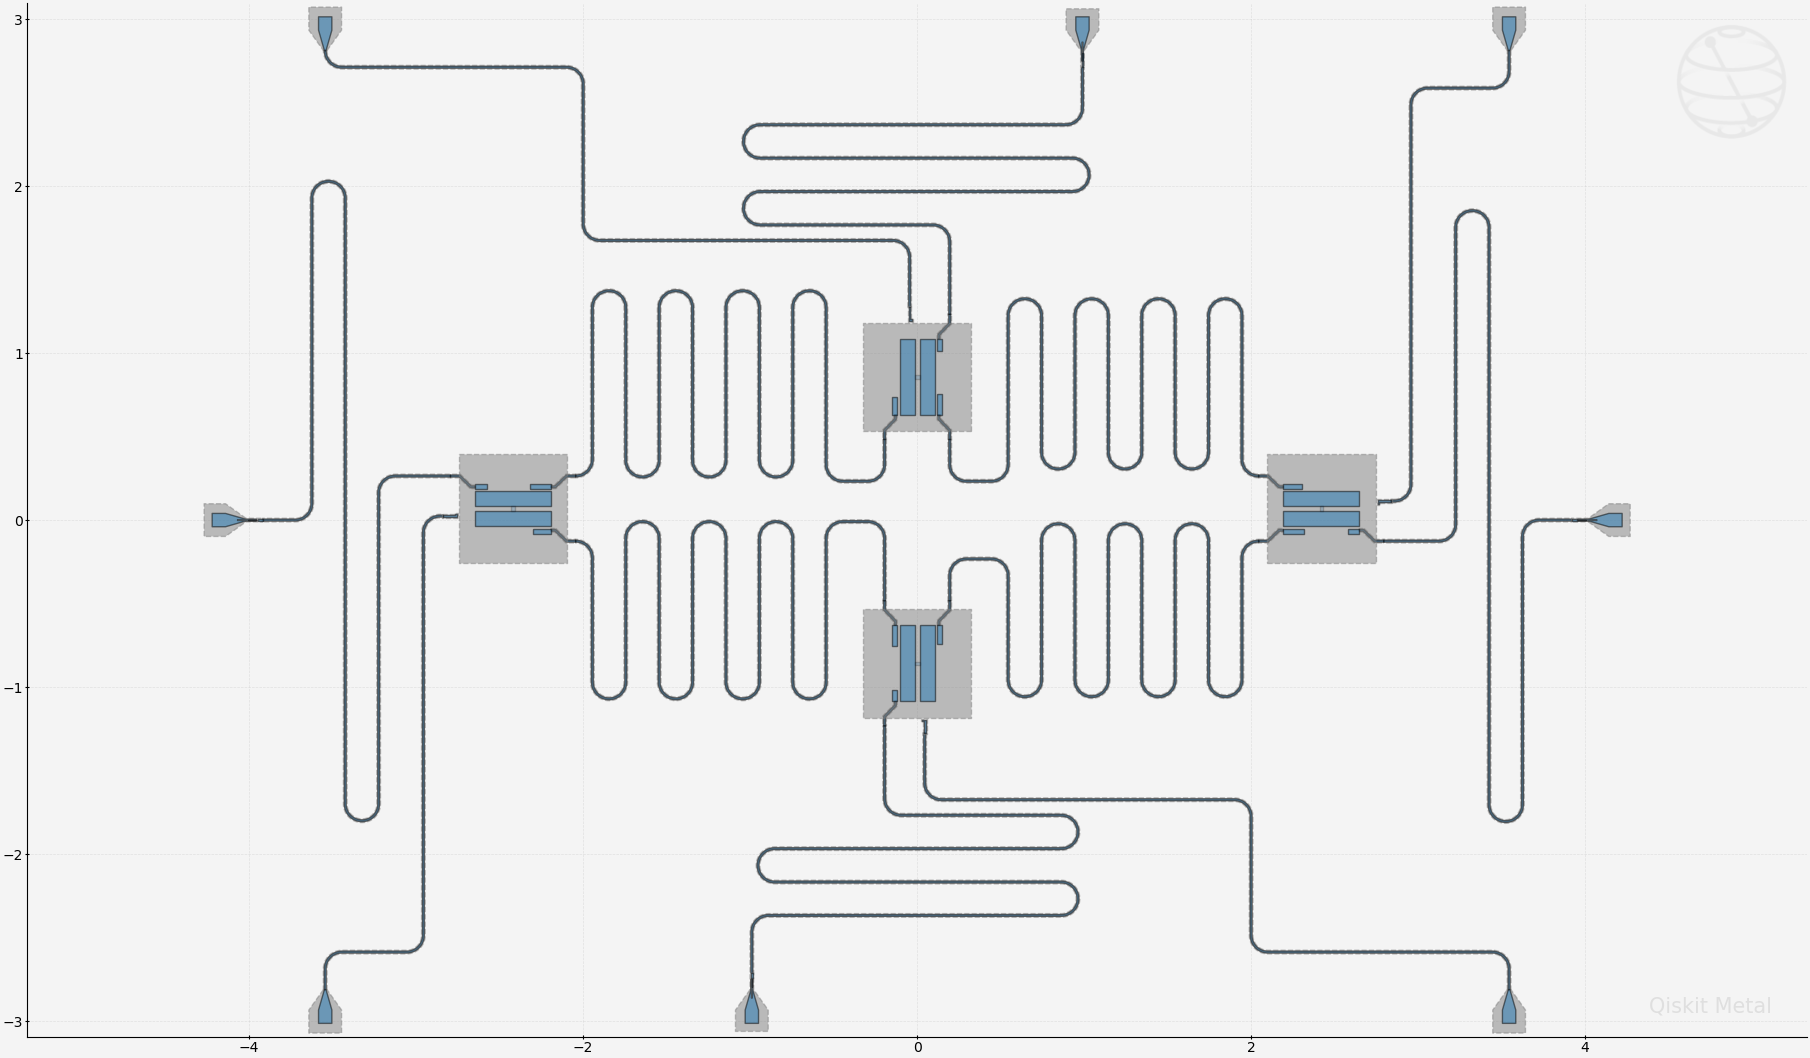

In [32]:
# Screenshot the canvas only as a .png formatted file.
# gui.screenshot()
gui.figure.savefig('shot.png')

from IPython.display import Image, display
_disp_ops = dict(width=500)
display(Image('shot.png', **_disp_ops))

![Chip design](shot.png)

In [33]:
# # Closing the Qiskit Metal GUI
# gui.main_window.close()

In [23]:
# with open("final_four_qubit_chip_design.py", "w") as f:
#     f.write(design.to_python_script())

# Simulation and Analysis

All the qubit parameters can initially be tuned via a capacitance matrix and the lumped oscillator method (LOM).

As a reminder, our target parameters are (approximately):
- qubit frequency => 4.8, 5, 5.2, 5.4 GHz
- qubit anharmonicity => 300 MHz
- qubit-bus coupling ($g_{q - bus}$) => 80 MHz
- qubit-readout ($\chi_{qc}$ ) => 1 MHz
- bus frequency 
    - Q1 (bus_12, bus_14) => 5.8, 6.0 GHz
    - Q2 (bus_23, bus_12) => 6.2, 5.8 GHz
    - Q3 (bus_34, bus_23) => 6.4, 6.2 GHz
    - Q4 (bus_14, bus_34) => 6.0, 6.4 GHz
- readout frequencies => 6.8, 7, 7.2, 7.4 GHz
- readout Q_external => 2000 ????

## Qubits and Lumped Oscillator Model (LOM)

In [24]:
from qiskit_metal.analyses.quantization import LOManalysis
lom_4qb = LOManalysis(design, "q3d")

In [25]:
lom_4qb.sim.setup

{'name': 'Setup',
 'reuse_selected_design': True,
 'reuse_setup': True,
 'freq_ghz': 5.0,
 'save_fields': False,
 'enabled': True,
 'max_passes': 15,
 'min_passes': 2,
 'min_converged_passes': 2,
 'percent_error': 0.5,
 'percent_refinement': 30,
 'auto_increase_solution_order': True,
 'solution_order': 'High',
 'solver_type': 'Iterative'}

In [26]:
lom_4qb.sim.setup.percent_error = 0.1
lom_4qb.sim.setup.max_passes = 20

In [27]:
lom_4qb.setup

{'junctions': {'Lj': 12, 'Cj': 2}, 'freq_readout': 7.0, 'freq_bus': [6.0, 6.2]}

In [28]:
lom_4qb.setup.freq_readout = 6.8
lom_4qb.setup.freq_bus = [5.8,6.0]
lom_4qb.setup

{'junctions': {'Lj': 12, 'Cj': 2}, 'freq_readout': 6.8, 'freq_bus': [5.8, 6.0]}

In [29]:
q1.pins.keys()

dict_keys(['readout', 'bus_12', 'bus_14', 'Charge_Line'])

In [30]:
q1.options

{'pos_x': '-2420um',
 'pos_y': '69um',
 'orientation': '180',
 'chip': 'main',
 'layer': '1',
 'connection_pads': {'readout': {'pad_gap': '15um',
   'pad_width': '70um',
   'pad_height': '30um',
   'pad_cpw_shift': '5um',
   'pad_cpw_extent': '25um',
   'cpw_width': 'cpw_width',
   'cpw_gap': 'cpw_gap',
   'cpw_extend': '50um',
   'pocket_extent': '5um',
   'pocket_rise': '65um',
   'loc_W': 1,
   'loc_H': -1},
  'bus_12': {'pad_gap': '15um',
   'pad_width': '125um',
   'pad_height': '30um',
   'pad_cpw_shift': '5um',
   'pad_cpw_extent': '25um',
   'cpw_width': 'cpw_width',
   'cpw_gap': 'cpw_gap',
   'cpw_extend': '50um',
   'pocket_extent': '5um',
   'pocket_rise': '65um',
   'loc_W': -1,
   'loc_H': -1},
  'bus_14': {'pad_gap': '15um',
   'pad_width': '110um',
   'pad_height': '30um',
   'pad_cpw_shift': '5um',
   'pad_cpw_extent': '25um',
   'cpw_width': 'cpw_width',
   'cpw_gap': 'cpw_gap',
   'cpw_extend': '50um',
   'pocket_extent': '5um',
   'pocket_rise': '65um',
   'loc_W': 

In [31]:
# disable CL geometry so Q3D doesn't see it as a net
for q in [q1, q2, q3, q4]:
    q.options.make_CL = False
gui.rebuild()

In [32]:
# sweep_data, return_code = lom_4qb.run_sweep(q1.name,
#                                        'pad_gap',
#                                        ['10um', '20um', '30um', '40um', '50um'],
#                                        render_design_argument_qcomps,
#                                        render_design_argument_endcaps,
#                                        design_name="GetCapacitance",
#                                        box_plus_buffer=True)

In [33]:
sweep_data, return_code = lom_4qb.run_sweep(q1.name,
                                    'pad_width',
                                    ['250um', '300um', '350um', '400um', '455um', '500um', '550um'],
                                    ['Q1'],
                                    [('Q1', 'readout'), ('Q1', 'bus_12'), ('Q1', 'bus_14')],
                                    design_name="GetCapacitance",
                                    box_plus_buffer=True)

INFO 03:00PM [connect_project]: Connecting to Ansys Desktop API...
INFO 03:00PM [load_ansys_project]: 	Opened Ansys App
INFO 03:00PM [load_ansys_project]: 	Opened Ansys Desktop v2021.1.0
INFO 03:00PM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/giann/Documents/Ansoft/
	Project:   Project27
INFO 03:00PM [connect_design]: 	Opened active design
	Design:    Three_Mode_v2_hfss [Solution type: Eigenmode]
INFO 03:00PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 03:00PM [connect]: 	Connected to project "Project27" and design "Three_Mode_v2_hfss" 😀 

INFO 03:00PM [connect_design]: 	Opened active design
	Design:    GetCapacitance_q3d [Solution type: Q3D]
INFO 03:00PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 03:00PM [analyze]: Analyzing setup Setup
INFO 03:02PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpz4k8qspq.txt, C, , Setup:LastAdaptive, "Original", "ohm", "nH", "fF", "

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 6.628853 [GHz]
EC 466.948268 [MHz]
EJ 13.616300 [GHz]
alpha -569.972845 [MHz]
dispersion 994.742752 [KHz]
Lq 11.995161 [nH]
Cq 41.482600 [fF]
T1 1.307698 [us]

**Coupling Properties**

tCqbus1 3.471008 [fF]
gbus1_in_MHz 72.457666 [MHz]
χ_bus1 -47.218528 [MHz]
1/T1bus1 118794.238553 [Hz]
T1bus1 1.339753 [us]

tCqbus2 5.438869 [fF]
gbus2_in_MHz 96.789090 [MHz]
χ_bus2 -49.841784 [MHz]
1/T1bus2 899.913854 [Hz]
T1bus2 176.855754 [us]

tCqbus3 -5.956483 [fF]
gbus3_in_MHz -109.693943 [MHz]
χ_bus3 -370.545011 [MHz]
1/T1bus3 2011.999566 [Hz]
T1bus3 79.102871 [us]
Bus-Bus Couplings
gbus1_2 7.922274 [MHz]
gbus1_3 5.061408 [MHz]
gbus2_3 6.849188 [MHz]


INFO 03:02PM [connect_design]: 	Opened active design
	Design:    GetCapacitance_q3d [Solution type: Q3D]
INFO 03:02PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 03:02PM [analyze]: Analyzing setup Setup
INFO 03:03PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpab5bw9h_.txt, C, , Setup:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 03:03PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpdb49g6v9.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 03:03PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpaas635rq.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 2, False
INFO 03:03PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpdvxdsv3u.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 6.227182 [GHz]
EC 407.637594 [MHz]
EJ 13.616300 [GHz]
alpha -488.473500 [MHz]
dispersion 357.954957 [KHz]
Lq 11.995161 [nH]
Cq 47.518257 [fF]
T1 6.942664 [us]

**Coupling Properties**

tCqbus1 3.589856 [fF]
gbus1_in_MHz 67.257454 [MHz]
χ_bus1 -7.296497 [MHz]
1/T1bus1 8568.392542 [Hz]
T1bus1 18.574656 [us]

tCqbus2 5.576666 [fF]
gbus2_in_MHz 89.064255 [MHz]
χ_bus2 295.927702 [MHz]
1/T1bus2 2703.481416 [Hz]
T1bus2 58.870367 [us]

tCqbus3 -5.947726 [fF]
gbus3_in_MHz -98.290174 [MHz]
χ_bus3 158.932329 [MHz]
1/T1bus3 11652.314506 [Hz]
T1bus3 13.658655 [us]
Bus-Bus Couplings
gbus1_2 6.084894 [MHz]
gbus1_3 4.573025 [MHz]
gbus2_3 6.202490 [MHz]


INFO 03:03PM [connect_design]: 	Opened active design
	Design:    GetCapacitance_q3d [Solution type: Q3D]
INFO 03:03PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 03:03PM [analyze]: Analyzing setup Setup
INFO 03:05PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpbbr5618m.txt, C, , Setup:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 03:05PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpraijzpxf.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 03:05PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpn2_hy3bb.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 2, False
INFO 03:05PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpbjp68mlg.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 

...

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 5.334863 [GHz]
EC 292.416851 [MHz]
EJ 13.616300 [GHz]
alpha -338.020312 [MHz]
dispersion 21.032714 [KHz]
Lq 11.995161 [nH]
Cq 66.241833 [fF]
T1 63.260457 [us]

**Coupling Properties**

tCqbus1 3.646470 [fF]
gbus1_in_MHz 52.614337 [MHz]
χ_bus1 -0.721457 [MHz]
1/T1bus1 677.949161 [Hz]
T1bus1 234.759407 [us]

tCqbus2 5.668829 [fF]
gbus2_in_MHz 69.716243 [MHz]
χ_bus2 -8.822792 [MHz]
1/T1bus2 1196.382677 [Hz]
T1bus2 133.030130 [us]

tCqbus3 -5.741961 [fF]
gbus3_in_MHz -73.064980 [MHz]
χ_bus3 -5.437876 [MHz]
1/T1bus3 641.535912 [Hz]
T1bus3 248.084230 [us]
Bus-Bus Couplings
gbus1_2 3.518016 [MHz]
gbus1_3 3.098034 [MHz]
gbus2_3 4.277647 [MHz]


INFO 03:08PM [connect_design]: 	Opened active design
	Design:    GetCapacitance_q3d [Solution type: Q3D]
INFO 03:08PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 03:08PM [analyze]: Analyzing setup Setup
INFO 03:10PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpmp945mpn.txt, C, , Setup:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 03:10PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpjgnjhjw6.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 03:10PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpwe2l6bp5.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 2, False
INFO 03:10PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpz1zmponn.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 5.136930 [GHz]
EC 269.802341 [MHz]
EJ 13.616300 [GHz]
alpha -309.627927 [MHz]
dispersion 9.789131 [KHz]
Lq 11.995161 [nH]
Cq 71.794144 [fF]
T1 127.596821 [us]

**Coupling Properties**

tCqbus1 3.618766 [fF]
gbus1_in_MHz 49.042481 [MHz]
χ_bus1 -0.464718 [MHz]
1/T1bus1 438.040689 [Hz]
T1bus1 363.333697 [us]

tCqbus2 5.653632 [fF]
gbus2_in_MHz 65.302823 [MHz]
χ_bus2 -4.117176 [MHz]
1/T1bus2 496.419650 [Hz]
T1bus2 320.605647 [us]

tCqbus3 -5.652854 [fF]
gbus3_in_MHz -67.558816 [MHz]
χ_bus3 -2.815994 [MHz]
1/T1bus3 312.866527 [Hz]
T1bus3 508.699172 [us]
Bus-Bus Couplings
gbus1_2 3.041431 [MHz]
gbus1_3 2.720099 [MHz]
gbus2_3 3.788255 [MHz]


INFO 03:10PM [connect_design]: 	Opened active design
	Design:    GetCapacitance_q3d [Solution type: Q3D]
INFO 03:10PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 03:10PM [analyze]: Analyzing setup Setup
INFO 03:12PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpfot3gs5e.txt, C, , Setup:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 03:12PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpgk00suyu.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 03:12PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpfrcouoaq.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 2, False
INFO 03:12PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpo7oih0e9.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 4.936359 [GHz]
EC 247.933853 [MHz]
EJ 13.616300 [GHz]
alpha -282.514198 [MHz]
dispersion 4.231803 [KHz]
Lq 11.995161 [nH]
Cq 78.126597 [fF]
T1 232.664711 [us]

**Coupling Properties**

tCqbus1 3.539385 [fF]
gbus1_in_MHz 44.921947 [MHz]
χ_bus1 -0.293560 [MHz]
1/T1bus1 279.581279 [Hz]
T1bus1 569.261803 [us]

tCqbus2 5.596221 [fF]
gbus2_in_MHz 60.533481 [MHz]
χ_bus2 -2.110076 [MHz]
1/T1bus2 240.941676 [Hz]
T1bus2 660.553815 [us]

tCqbus3 -5.495885 [fF]
gbus3_in_MHz -61.511182 [MHz]
χ_bus3 -1.511446 [MHz]
1/T1bus3 163.529828 [Hz]
T1bus3 973.247173 [us]
Bus-Bus Couplings
gbus1_2 2.547591 [MHz]
gbus1_3 2.297348 [MHz]
gbus2_3 3.252916 [MHz]


In [34]:
first_key = list(sweep_data.keys())[0]
cap = sweep_data[first_key]['sim_variables']['cap_matrix']
print(list(cap.index))

['bus_12_connector_pad_Q1', 'bus_14_connector_pad_Q1', 'ground_main_plane', 'pad_bot_Q1', 'pad_top_Q1', 'readout_connector_pad_Q1']


In [35]:
sweep_data['250um']['variables']['lumped_oscillator']

{'fQ': 6.628852502207465,
 'EC': 466.9482676402248,
 'EJ': 13.616300010297985,
 'alpha': -569.972844875857,
 'dispersion': 994.7427523059845,
 'gbus': array([  72.45766578,   96.78909024, -109.69394335]),
 'chi_in_MHz': array([ -47.21852773,  -49.84178446, -370.54501085])}

In [36]:
from pandas import DataFrame

ec_val = []
for opt_val in sweep_data.keys():
    ec_val.append([
        opt_val,
        sweep_data[opt_val]['variables']['lumped_oscillator']['fQ'],
        sweep_data[opt_val]['variables']['lumped_oscillator']['EC'],
        sweep_data[opt_val]['variables']['lumped_oscillator']['EJ'], 
        sweep_data[opt_val]['variables']['lumped_oscillator']['alpha']
        ])

df=DataFrame(ec_val,columns = ['Sweep Value', 'fQ', 'Ec', 'Ej', 'alpha'])
df

,Sweep Value,fQ,Ec,Ej,alpha
0,250um,6.628853,466.948268,13.6163,-569.972845
1,300um,6.227182,407.637594,13.6163,-488.473500
2,350um,5.889106,361.365858,13.6163,-426.856325
3,400um,5.605346,325.014823,13.6163,-379.588349
4,455um,5.334863,292.416851,13.6163,-338.020312
5,500um,5.136930,269.802341,13.6163,-309.627927
6,550um,4.936359,247.933853,13.6163,-282.514198


In [37]:
# disable CL geometry so Q3D doesn't see it as a net
optimal_pad_width = '455um'

for q in [q1, q2, q3, q4]:
    q.options.make_CL = False
    q.options.pad_width = '455um'
gui.rebuild()

## EJ and Lj Targets — pad_width = 350 µm

**EC = 291.12 MHz** (same for all qubits, set by pad geometry)  
**|α| ≈ 291 MHz** (same for all qubits)

| Qubit | Target fQ (GHz) | EJ (GHz) | Lj (nH) | EJ/EC |
|-------|----------------|----------|---------|-------|
| Q1    | 4.8            | 11.086   | 14.745  | 37.9  |
| Q2    | 5.0            | 11.974   | 13.652  | 40.9  |
| Q3    | 5.2            | 12.896   | 12.676  | 44.1  |
| Q4    | 5.4            | 13.852   | 11.801  | 47.4  |

### Formula used

$$f_Q \approx \sqrt{8 E_J E_C} - E_C$$

$$E_J = \frac{(f_Q + E_C)^2}{8 E_C}$$

$$L_j = \frac{(\Phi_0 / 2\pi)^2}{E_J h}$$

where $\Phi_0 = 2.068 \times 10^{-15}$ Wb.

> **Note:** Bus resonator frequencies are set to [6.8, 7.0, 7.2, 7.4] GHz in the LOM setup.  


In [87]:
import numpy as np
from scipy.constants import h, e
import pandas as pd

# EC_MHz = sweep_data['350um']['variables']['lumped_oscillator']['EC']
EC_MHz = 292.41
EC = EC_MHz * 1e6 # Hz
Phi0 = h / (2 * e)

target_fQ_GHz = [4.8, 5, 5.2, 5.4]

rows = []
for fQ_GHz in target_fQ_GHz:
    fQ = fQ_GHz * 1e9
    EJ = (fQ + EC)**2 / (8 * EC)
    Lj = (Phi0 / (2 * np.pi))**2 / (EJ * h)
    rows.append({
        'Qubit'         : f'Q{target_fQ_GHz.index(fQ_GHz)+1}',
        'fQ (GHz)'      : round(fQ_GHz, 1),
        'EJ (GHz)'      : round(EJ / 1e9, 3),
        'Lj (nH)'       : round(Lj * 1e9, 3),
        'EJ/EC'         : round(EJ / EC, 1),
    })

df = pd.DataFrame(rows)
print(f"EC  = {EC_MHz:.3f} MHz  (pad_width = 350um)")
print()
print(df.to_string(index=False))

EC  = 292.410 MHz  (pad_width = 350um)

Qubit  fQ (GHz)  EJ (GHz)  Lj (nH)  EJ/EC
   Q1       4.8    11.086   14.745   37.9
   Q2       5.0    11.974   13.652   40.9
   Q3       5.2    12.896   12.676   44.1
   Q4       5.4    13.852   11.801   47.4


In [39]:
lom_4qb.setup.junctions.Lj = 14.745

In [40]:
lom_4qb.run(components=['Q1'], open_terminations=[('Q1', 'readout'), ('Q1', 'bus_12'), ('Q1', 'bus_14')])

INFO 03:12PM [connect_design]: 	Opened active design
	Design:    Design_q3d [Solution type: Q3D]
INFO 03:12PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 03:12PM [analyze]: Analyzing setup Setup
INFO 03:13PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpqwc20wib.txt, C, , Setup:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 03:13PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpxc9298s_.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 1, False
INFO 03:13PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpzdote2y6.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 5000000000, Maxwell, 2, False
INFO 03:13PM [get_matrix]: Exporting matrix data to (C:\Users\giann\AppData\Local\Temp\tmpgh72izfw.txt, C, , Setup:AdaptivePass, "Original", "ohm", "nH", "fF", "mSie", 50000000

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 4.780054 [GHz]
EC 292.416851 [MHz]
EJ 11.081424 [GHz]
alpha -345.190753 [MHz]
dispersion 105.213021 [KHz]
Lq 14.739054 [nH]
Cq 66.241833 [fF]
T1 250.256180 [us]

**Coupling Properties**

tCqbus1 3.646470 [fF]
gbus1_in_MHz 49.973322 [MHz]
χ_bus1 -0.374138 [MHz]
1/T1bus1 283.667948 [Hz]
T1bus1 561.060719 [us]

tCqbus2 5.668829 [fF]
gbus2_in_MHz 66.216785 [MHz]
χ_bus2 -2.202017 [MHz]
1/T1bus2 199.599601 [Hz]
T1bus2 797.371049 [us]

tCqbus3 -5.741961 [fF]
gbus3_in_MHz -69.397430 [MHz]
χ_bus3 -1.770895 [MHz]
1/T1bus3 152.700535 [Hz]
T1bus3 1042.268407 [us]
Bus-Bus Couplings
gbus1_2 3.518016 [MHz]
gbus1_3 3.098034 [MHz]
gbus2_3 4.277647 [MHz]


,fQ,EC,EJ,alpha,dispersion,gbus,chi_in_MHz,χr MHz,gr MHz
1,5.139917,342.049894,11.081424,-411.491856,369.075649,"[41.2695348422801, 64.60264148610109, -56.0778...","[-0.4177697506171767, -4.8857320820389765, -2....",0.417770,41.269535
2,5.071987,332.329297,11.081424,-398.319242,295.307868,"[46.592653006504925, 64.36565209320901, -64.43...","[-0.48336760834721715, -4.0539640274531505, -2...",0.483368,46.592653
3,5.004483,322.833283,11.081424,-385.540616,235.169225,"[48.36993594453409, 61.405741011943974, -65.93...","[-0.47405848839300335, -3.1203765225675095, -2...",0.474058,48.369936
4,4.938339,313.685401,11.081424,-373.312981,186.981608,"[48.031637668054834, 61.772133454839086, -65.2...","[-0.4268966924467132, -2.702876525140175, -2.1...",0.426897,48.031638
5,4.89748,308.111567,11.081424,-365.901843,161.77551,"[48.46250340827589, 62.54610829459888, -65.923...","[-0.4112142623321605, -2.526678882505826, -1.9...",0.411214,48.462503
6,4.856384,302.564242,11.081424,-358.555124,139.498918,"[49.150710702136706, 63.83836209108562, -67.24...","[-0.4003210537160193, -2.4050371277077858, -1....",0.400321,49.150711
7,4.833066,299.442827,11.081424,-354.433918,128.105011,"[49.03891671182696, 64.65408923953535, -67.678...","[-0.3863399327887434, -2.3463019390593285, -1....",0.386340,49.038917
8,4.816983,297.300952,11.081424,-351.611266,120.734231,"[49.255551787768, 65.18592543746429, -67.97595...","[-0.381554663557112, -2.3050239851033743, -1.8...",0.381555,49.255552
9,4.802932,295.437038,11.081424,-349.158401,114.604706,"[49.480225976517715, 65.47665910998415, -68.63...","[-0.3779757122981564, -2.2579346812403993, -1....",0.377976,49.480226
10,4.796106,294.534072,11.081424,-347.971279,111.727904,"[49.583812669452946, 65.72531809636993, -68.73...","[-0.3761674745703468, -2.2429087464820245, -1....",0.376167,49.583813


In [41]:
lom_4qb.plot_convergence()
lom_4qb.plot_convergence_chi()

Design "Design_q3d" info:
	# eigenmodes    0
	# variations    1


INFO 03:13PM [hfss_report_full_convergence]: Creating report for variation 0


In [42]:
lom_4qb.sim.capacitance_matrix

,bus_12_connector_pad_Q1,bus_14_connector_pad_Q1,ground_main_plane,pad_bot_Q1,pad_top_Q1,readout_connector_pad_Q1
bus_12_connector_pad_Q1,41.72229,-0.26794,-25.43433,-13.49325,-1.52436,-0.17743
bus_14_connector_pad_Q1,-0.26794,39.59180,-24.79187,-1.38770,-12.29644,-0.07431
ground_main_plane,-25.43433,-24.79187,209.72416,-38.39668,-42.15744,-22.94845
pad_bot_Q1,-13.49325,-1.38770,-38.39668,99.55247,-34.47020,-8.87822
pad_top_Q1,-1.52436,-12.29644,-42.15744,-34.47020,94.75689,-1.16321
readout_connector_pad_Q1,-0.17743,-0.07431,-22.94845,-8.87822,-1.16321,33.88605


In [43]:
lom_4qb.lumped_oscillator

{'fQ': 4.780054025089595,
 'EC': 292.41685077854737,
 'EJ': 11.081424219978018,
 'alpha': -345.19075265579295,
 'dispersion': 105.21302053451538,
 'gbus': array([ 49.97332153,  66.21678494, -69.39743021]),
 'chi_in_MHz': array([-0.37413779, -2.20201716, -1.77089541])}

### Simulation also for connection pads on the qubits should be made
LOM analysis is specifically for the qubit, it cannot be used for the resonator!
- q1.options.connection_pads.readout.pad_gap
- q1.options.connection_pads.readout.pad_width
- q1.options.connection_pads.bus_01.pad_width
- q1.options.connection_pads.bus_02.pad_width

The relationships:

- Larger pad_width on connection pad → stronger coupling → higher g → higher χ
- Smaller pad_gap on connection pad → coupling pad closer to island → stronger coupling

In [44]:
# save_dir = r'C:\Users\giann\Projects\quantum-metal\qiskit-metal-simulations\results\chapter_a'
# os.makedirs(save_dir, exist_ok=True)

# for gap, data in sweep_data.items():
#     cap_matrix = data['sim_variables']['cap_matrix']
#     cap_matrix.to_csv(os.path.join(save_dir, f'cap_matrix_{gap}.csv'))

In [45]:
# cap_30um = pd.read_csv(os.path.join(save_dir, 'cap_matrix_20um.csv'), index_col=0)
# cap_30um

In [46]:
lom_4qb.sim.close()

## Resonator and Eigenmode Simulations

We will focus on `bus_12` for this step.

In [47]:
for q in [q1, q2, q3, q4]:
    q.options.make_CL = True
gui.rebuild()

In [48]:
optimal_pad_width = '455um'
pad_width = optimal_pad_width

for name, q in zip(['Q1','Q2','Q3','Q4'], [q1,q2,q3,q4]):
    q.options.pad_width = pad_width
    q.options['hfss_inductance'] = f'Lj_{name}'
    q.options['hfss_capacitance'] = f'Cj_{name}'
gui.rebuild()

In [49]:
from qiskit_metal.analyses.sweep_and_optimize.sweeping import Sweeping
sweep = Sweeping(design)

In [50]:
?sweep.sweep_one_option_get_eigenmode_solution_data

Signature:
sweep.sweep_one_option_get_eigenmode_solution_data(
    qcomp_name: str,
    option_name: str,
    option_sweep: list,
    qcomp_render: list,
    endcaps_render: list,
    ignored_jjs_render: list,
    box_plus_buffer_render: bool = True,
    setup_args: addict.addict.Dict = None,
    leave_last_design: bool = True,
    design_name: str = 'Sweep_Eigenmode',
) -> typing.Tuple[addict.addict.Dict, int]
Docstring:
Ansys must be open with inserted project. A design, "HFSS Design"
with eigenmode solution-type will be inserted by this method.

Args:
    qcomp_name (str): A component that contains the option to be
                        swept. Assume qcomp_name is in qcomp_render.
    option_name (str): The option within qcomp_name to sweep.
                        Follow details from
                        renderer in QHFSSRenderer.render_design.
    option_sweep (list): Each entry in the list is a value for
                        option_name.
    qcomp_render(list): List of co

In [51]:
em_setup_args = Dict(min_freq_ghz=3,
                    n_modes=2,
                    max_passes=15,
                    max_delta_f = 0.05)

all_sweeps, return_code = sweep.sweep_one_option_get_eigenmode_solution_data(
    'cpw1',
    'total_length',
    ['9.61mm', '9.71mm', '9.81mm'],
    # ['9.91mm','10.01mm', '10.11mm', '10.21mm', '10.31mm', '10.41mm', '10.51mm', '10.61mm'],
    ['Q1','Q2','cpw1'],
    [],
    [('Q1','rect_jj'),('Q2','rect_jj')],
    design_name="GetEigenModeSolution",
    box_plus_buffer_render=False,
    setup_args=em_setup_args)

INFO 03:13PM [connect_project]: Connecting to Ansys Desktop API...
INFO 03:13PM [load_ansys_project]: 	Opened Ansys App
INFO 03:13PM [load_ansys_project]: 	Opened Ansys Desktop v2021.1.0
INFO 03:13PM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/giann/Documents/Ansoft/
	Project:   Project27
INFO 03:13PM [connect_design]: 	Opened active design
	Design:    Design_q3d [Solution type: Q3D]
INFO 03:13PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 03:13PM [connect]: 	Connected to project "Project27" and design "Design_q3d" 😀 

INFO 03:13PM [connect_design]: 	Opened active design
	Design:    GetEigenModeSolution [Solution type: Eigenmode]
INFO 03:13PM [get_setup]: 	Opened setup `Sweep_em_setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 03:14PM [get_setup]: 	Opened setup `Sweep_em_setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 03:14PM [analyze]: Analyzing setup Sweep_em_setup
03:21PM 07s INFO [get_f_convergence]: Saved convergences to c:\

03:36PM 00s CRITICAL [_qt_message_handler]: line: 0, func: None(), file: None  CRITICAL: QEventDispatcherWin32::wakeUp: Failed to post a message (Not enough quota is available to process this command.)



In [52]:
frequency = {}
for key in all_sweeps.keys():
    frequency[key] = all_sweeps[key]['frequency']

frequency

{'9.61mm': [5.88790387403, 6.01571977225],
 '9.71mm': [5.83076378657, 5.97707925176],
 '9.81mm': [5.77346848929, 5.94487791642]}

In [53]:
all_sweeps['9.71mm']

{'convergence': False,
 'option_name': 'total_length',
 'frequency': [5.83076378657, 5.97707925176],
 'kappa_over_2pis': None,
 'quality_factor': None,
 'convergence_eig_f':          re(Mode(1)) [g]  re(Mode(2)) [g]
 Pass []                                  
 1               4.663349         5.528654
 2               3.849696         5.203461
 3               4.654950         5.209699
 4               4.950745         5.213997
 5               5.344109         5.447577
 6               5.557579         5.600570
 7               5.643716         5.702167
 8               5.723896         5.804010
 9               5.786954         5.866952
 10              5.819163         5.908951
 11              5.831925         5.937620
 12              5.836996         5.952833
 13              5.839306         5.963358
 14              5.834528         5.971381
 15              5.830764         5.977079,
 'convergence_t':              Solved Elements  Max Delta Freq. %
 Pass Number                 

In [54]:
cpw1.options.total_length = '9.71mm'
gui.rebuild()

In [55]:
from qiskit_metal.analyses.quantization import EPRanalysis
eig_4qb_ps = EPRanalysis(design, "hfss")

In [56]:
eig_4qb_ps.sim.setup

{'name': 'Setup',
 'reuse_selected_design': True,
 'reuse_setup': True,
 'min_freq_ghz': 1,
 'n_modes': 1,
 'max_delta_f': 0.5,
 'max_passes': 10,
 'min_passes': 1,
 'min_converged': 1,
 'pct_refinement': 30,
 'basis_order': 1,
 'vars': {'Lj': '10 nH', 'Cj': '0 fF'}}

In [57]:
eig_4qb_ps.sim.renderer.options['x_buffer_width_mm'] = 1 # tune to 1.0–2.0 mm, default was 0.5
eig_4qb_ps.sim.renderer.options['y_buffer_width_mm'] = 1 # tune to 1.0–2.0 mm

In [58]:
eig_4qb_ps.sim.setup.n_modes = 2
eig_4qb_ps.sim.setup.max_passes = 16
eig_4qb_ps.sim.setup.max_delta_f = 0.05
eig_4qb_ps.sim.setup.vars = Dict(
    Lj_Q1='14.745 nH', Cj_Q1='0 fF',
    Lj_Q2='13.652 nH', Cj_Q2='0 fF',
    Lj_Q3='12.676 nH',  Cj_Q3='0 fF',
    Lj_Q4='11.801 nH',  Cj_Q4='0 fF',
)

In [59]:
eig_4qb_ps.sim.print_run_args()

This analysis object run with the following kwargs:
{}



In [60]:
# List every component and its pins
for comp_name, comp in design.components.items():
    for pin_name in comp.pins:
        net = comp.pins[pin_name].get('net_id', None)
        print(f"({comp_name!r}, {pin_name!r})  net={net}")

('Q1', 'readout')  net=445
('Q1', 'bus_12')  net=437
('Q1', 'bus_14')  net=443
('Q1', 'Charge_Line')  net=453
('Q2', 'readout')  net=449
('Q2', 'bus_23')  net=440
('Q2', 'bus_12')  net=438
('Q2', 'Charge_Line')  net=457
('Q3', 'readout')  net=447
('Q3', 'bus_34')  net=441
('Q3', 'bus_23')  net=439
('Q3', 'Charge_Line')  net=455
('Q4', 'readout')  net=451
('Q4', 'bus_14')  net=444
('Q4', 'bus_34')  net=442
('Q4', 'Charge_Line')  net=459
('cpw1', 'start')  net=437
('cpw1', 'end')  net=438
('cpw2', 'start')  net=439
('cpw2', 'end')  net=440
('cpw3', 'start')  net=441
('cpw3', 'end')  net=442
('cpw4', 'start')  net=443
('cpw4', 'end')  net=444
('Launch_CL_Q1', 'tie')  net=454
('Launch_CL_Q2', 'tie')  net=458
('Launch_CL_Q3', 'tie')  net=456
('Launch_CL_Q4', 'tie')  net=460
('Launch_RO_Q1', 'tie')  net=446
('Launch_RO_Q2', 'tie')  net=450
('Launch_RO_Q3', 'tie')  net=448
('Launch_RO_Q4', 'tie')  net=452
('Readout1', 'start')  net=445
('Readout1', 'end')  net=446
('Readout3', 'start')  net=4

In [61]:
eig_4qb_ps.sim.run_sim(name="Bus_12_Sim_v2", 
                       components=['Q1','Q2','cpw1'],
                       ignored_jjs = [('Q1','rect_jj'),('Q2','rect_jj')], 
                       open_terminations=[],
                       box_plus_buffer = False)

INFO 03:36PM [connect_project]: Connecting to Ansys Desktop API...
INFO 03:36PM [load_ansys_project]: 	Opened Ansys App
INFO 03:36PM [load_ansys_project]: 	Opened Ansys Desktop v2021.1.0
INFO 03:36PM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/giann/Documents/Ansoft/
	Project:   Project27
INFO 03:36PM [connect_design]: 	Opened active design
	Design:    GetEigenModeSolution [Solution type: Eigenmode]
INFO 03:36PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 03:36PM [connect]: 	Connected to project "Project27" and design "GetEigenModeSolution" 😀 

INFO 03:36PM [connect_design]: 	Opened active design
	Design:    Bus_12_Sim_v2_hfss [Solution type: Eigenmode]
INFO 03:36PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 03:36PM [analyze]: Analyzing setup Setup
03:39PM 37s INFO [get_f_convergence]: Saved convergences to c:\Users\giann\Projects\quantum-metal\qiskit-metal-simulations\hfss_eig_f_convergence.csv


('Bus_12_Sim_v2_hfss', 'Setup')

In [62]:
eig_4qb_ps.sim.plot_convergences()

In [63]:
eig_4qb_ps.get_frequencies()

Design "Bus_12_Sim_v2_hfss" info:
	# eigenmodes    2
	# variations    1
Design "Bus_12_Sim_v2_hfss" info:
	# eigenmodes    2
	# variations    1


Freq. (GHz)  Quality Factor
variation mode                             
0         0        5.838797             inf
          1        5.946659             inf

In [64]:
eig_4qb_ps.sim.convergence_f

,re(Mode(1)) [g],re(Mode(2)) [g]
Pass [],,
1,3.788694,4.110439
2,1.649769,3.353874
3,2.695476,3.190676
4,3.305310,3.970851
5,4.153189,4.279759
6,4.689659,4.818322
7,5.011785,5.185009
8,5.286924,5.397906
9,5.453224,5.558844


In [65]:
q1.qgeometry_table('junction')

,component,name,geometry,layer,subtract,helper,chip,width,hfss_inductance,hfss_capacitance,...,hfss_mesh_kw_jj,q3d_inductance,q3d_capacitance,q3d_resistance,q3d_mesh_kw_jj,gds_cell_name,aedt_q3d_inductance,aedt_q3d_capacitance,aedt_hfss_inductance,aedt_hfss_capacitance
0,1,rect_jj,"LINESTRING (-2.42000 0.08400, -2.42000 0.05400)",1,False,False,main,0.02,Lj_Q1,Cj_Q1,...,0.000007,10nH,0,0,0.000007,FakeJunction_01,1.000000e-08,0,1.000000e-08,0


In [66]:
eig_4qb_ps.sim.plot_fields('main')

INFO 03:39PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)


In [67]:
eig_4qb_ps.sim.plot_fields('main', eigenmode=3)

INFO 03:39PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
03:39PM 41s WARNING [set_mode]: The requested mode=3 is not a valid (1 to 2) selection. The mode was not set.


In [68]:
eig_4qb_ps.sim.close()

### EPR Analysis

In [69]:
from qiskit_metal.analyses.quantization import EPRanalysis
eig_4qb_ps = EPRanalysis(design, "hfss")

In [70]:
eig_4qb_ps.setup

{'junctions': {'jj': {'Lj_variable': 'Lj',
   'Cj_variable': 'Cj',
   'rect': '',
   'line': ''}},
 'dissipatives': {'dielectrics_bulk': ['main']},
 'cos_trunc': 8,
 'fock_trunc': 7,
 'sweep_variable': 'Lj'}

In [71]:
for q in [q1, q2, q3, q4]:
    q.options.make_CL = True
gui.rebuild()

optimal_pad_width = '455um'
pad_width = optimal_pad_width

for name, q in zip(['Q1','Q2','Q3','Q4'], [q1,q2,q3,q4]):
    q.options.pad_width = pad_width
    q.options['hfss_inductance'] = f'Lj_{name}'
    q.options['hfss_capacitance'] = f'Cj_{name}'

cpw1.options.total_length = '9.71mm'
gui.rebuild()

eig_4qb_ps.sim.renderer.options['x_buffer_width_mm'] = 1 # tune to 1.0–2.0 mm, default was 0.5
eig_4qb_ps.sim.renderer.options['y_buffer_width_mm'] = 1 # tune to 1.0–2.0 mm

eig_4qb_ps.sim.setup.n_modes = 3
eig_4qb_ps.sim.setup.max_passes = 15
eig_4qb_ps.sim.setup.max_delta_f = 0.05
eig_4qb_ps.sim.setup.vars = Dict(
    Lj_Q1='16.1 nH', Cj_Q1='0 fF',  # 14.745 nH
    Lj_Q2='14.9 nH', Cj_Q2='0 fF',  # 13.652
    Lj_Q3='12.676 nH',  Cj_Q3='0 fF',
    Lj_Q4='11.801 nH',  Cj_Q4='0 fF',
)

In [72]:
eig_4qb_ps.sim.setup

{'name': 'Setup',
 'reuse_selected_design': True,
 'reuse_setup': True,
 'min_freq_ghz': 1,
 'n_modes': 3,
 'max_delta_f': 0.05,
 'max_passes': 15,
 'min_passes': 1,
 'min_converged': 1,
 'pct_refinement': 30,
 'basis_order': 1,
 'vars': {'Lj_Q1': '16.1 nH',
  'Cj_Q1': '0 fF',
  'Lj_Q2': '14.9 nH',
  'Cj_Q2': '0 fF',
  'Lj_Q3': '12.676 nH',
  'Cj_Q3': '0 fF',
  'Lj_Q4': '11.801 nH',
  'Cj_Q4': '0 fF'}}

In [73]:
# eig_4qb_ps.setup.cos_trunc = 6 # anharmonicity α accuracy
# eig_4qb_ps.setup.fock_trunc = 6  # most important reduction, higher order corrections to fQ, g, χ 4 is sufficient for fQ and g

In [74]:
eig_4qb_ps.sim.run_sim(name="Three_Mode_v2",
            components=['Q1', 'Q2', 'cpw1'],
            box_plus_buffer = False)

INFO 03:39PM [connect_project]: Connecting to Ansys Desktop API...
INFO 03:39PM [load_ansys_project]: 	Opened Ansys App
INFO 03:39PM [load_ansys_project]: 	Opened Ansys Desktop v2021.1.0
INFO 03:39PM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/giann/Documents/Ansoft/
	Project:   Project27
INFO 03:39PM [connect_design]: 	Opened active design
	Design:    Bus_12_Sim_v2_hfss [Solution type: Eigenmode]
INFO 03:39PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 03:39PM [connect]: 	Connected to project "Project27" and design "Bus_12_Sim_v2_hfss" 😀 

INFO 03:39PM [connect_design]: 	Opened active design
	Design:    Three_Mode_v2_hfss [Solution type: Eigenmode]
INFO 03:40PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 03:40PM [analyze]: Analyzing setup Setup
03:50PM 15s INFO [get_f_convergence]: Saved convergences to c:\Users\giann\Projects\quantum-metal\qiskit-metal-simulations\hfss_eig_f_convergence.csv


('Three_Mode_v2_hfss', 'Setup')

In [75]:
eig_4qb_ps.sim.plot_convergences()

In [76]:
eig_4qb_ps.get_frequencies()

Design "Three_Mode_v2_hfss" info:
	# eigenmodes    3
	# variations    1
Design "Three_Mode_v2_hfss" info:
	# eigenmodes    3
	# variations    1


Freq. (GHz)  Quality Factor
variation mode                             
0         0        4.788531             inf
          1        4.984812             inf
          2        5.844485             inf

In [ ]:
eig_4qb_ps.sim.plot_fields('main', eigenmode=1)

INFO 05:10PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)


04:05PM 25s CRITICAL [_qt_message_handler]: line: 0, func: None(), file: None  WARNING: monitorData: Unable to obtain handle for monitor '\\.\DISPLAY1', defaulting to 96 DPI.

04:05PM 25s CRITICAL [_qt_message_handler]: line: 0, func: None(), file: None  WARNING: monitorData: Unable to obtain handle for monitor '\\.\DISPLAY2', defaulting to 96 DPI.

04:05PM 25s CRITICAL [_qt_message_handler]: line: 0, func: None(), file: None  WARNING: monitorData: Unable to obtain handle for monitor '\\.\DISPLAY1', defaulting to 96 DPI.

04:05PM 25s CRITICAL [_qt_message_handler]: line: 0, func: None(), file: None  WARNING: monitorData: Unable to obtain handle for monitor '\\.\DISPLAY2', defaulting to 96 DPI.

04:05PM 25s CRITICAL [_qt_message_handler]: line: 0, func: None(), file: None  WARNING: monitorData: Unable to obtain handle for monitor '\\.\DISPLAY1', defaulting to 96 DPI.

04:05PM 25s CRITICAL [_qt_message_handler]: line: 0, func: None(), file: None  WARNING: monitorData: Unable to obtain ha

In [77]:
eig_4qb_ps.del_junction()

eig_4qb_ps.add_junction('jj1', 'Lj_Q1', 'Cj_Q1', rect='JJ_rect_Lj_Q1_rect_jj', line='JJ_Lj_Q1_rect_jj_')
eig_4qb_ps.add_junction('jj2', 'Lj_Q2', 'Cj_Q2', rect='JJ_rect_Lj_Q2_rect_jj', line='JJ_Lj_Q2_rect_jj_')
# eig_4qb_ps.add_junction('jj3', 'Lj_Q3', 'Cj_Q3', rect='JJ_rect_Lj_Q3_rect_jj', line='JJ_Lj_Q3_rect_jj_')
# eig_4qb_ps.add_junction('jj4', 'Lj_Q4', 'Cj_Q4', rect='JJ_rect_Lj_Q4_rect_jj', line='JJ_Lj_Q4_rect_jj_')
eig_4qb_ps.setup.sweep_variable = 'variation' # 'variation'

In [78]:
eig_4qb_ps.run_epr()

Design "Three_Mode_v2_hfss" info:
	# eigenmodes    3
	# variations    1
Design "Three_Mode_v2_hfss" info:
	# eigenmodes    3
	# variations    1

        energy_elec_all       = 1.6156039101074e-24
        energy_elec_substrate = 1.48699211689195e-24
        EPR of substrate = 92.0%

        energy_mag    = 1.36979133775183e-26
        energy_mag % of energy_elec_all  = 0.8%
        

Variation 0  [1/1]

  Mode 0 at 4.79 GHz   [1/3]
    Calculating ℰ_magnetic,ℰ_electric
       (ℰ_E-ℰ_H)/ℰ_E       ℰ_E       ℰ_H
               99.2%  8.078e-25 6.849e-27

    Calculating junction energy participation ration (EPR)
	method=`line_voltage`. First estimates:
	junction        EPR p_0j   sign s_0j    (p_capacitive)
		Energy fraction (Lj over Lj&Cj)= 97.17%
	jj1              0.99005  (+)        0.0288587
		Energy fraction (Lj over Lj&Cj)= 97.37%
	jj2             0.000279363  (+)        7.53616e-06
		(U_tot_cap-U_tot_ind)/mean=1.48%
Calculating Qdielectric_main for mode 0 (0/2)


  sol = sol.append(self.get_Qdielectric(



p_dielectric_main_0 = 0.9203939824539665

  Mode 1 at 4.98 GHz   [2/3]
    Calculating ℰ_magnetic,ℰ_electric
       (ℰ_E-ℰ_H)/ℰ_E       ℰ_E       ℰ_H
               98.9%  6.584e-25 7.178e-27

    Calculating junction energy participation ration (EPR)
	method=`line_voltage`. First estimates:
	junction        EPR p_1j   sign s_1j    (p_capacitive)
		Energy fraction (Lj over Lj&Cj)= 96.94%
	jj1             0.000436125  (+)        1.3776e-05
		Energy fraction (Lj over Lj&Cj)= 97.16%
	jj2             0.988433  (+)        0.0288949
		(U_tot_cap-U_tot_ind)/mean=1.44%
Calculating Qdielectric_main for mode 1 (1/2)


  sol = sol.append(self.get_Qdielectric(



p_dielectric_main_1 = 0.9208255715194869

  Mode 2 at 5.84 GHz   [3/3]
    Calculating ℰ_magnetic,ℰ_electric
       (ℰ_E-ℰ_H)/ℰ_E       ℰ_E       ℰ_H
                1.0%  1.888e-24 1.869e-24

    Calculating junction energy participation ration (EPR)
	method=`line_voltage`. First estimates:
	junction        EPR p_2j   sign s_2j    (p_capacitive)
		Energy fraction (Lj over Lj&Cj)= 95.84%
	jj1             0.0036545  (+)        0.000158685
		Energy fraction (Lj over Lj&Cj)= 96.14%
	jj2             0.00647476  (+)        0.000260191
		(U_tot_cap-U_tot_ind)/mean=0.02%
Calculating Qdielectric_main for mode 2 (2/2)


...

###### Numerical diagonalization

variation,0
0,4490.55
1,4687.07
2,5841.74


#### Kerr Non-linear coefficient table (MHz)

###### Numerical diagonalization

0       1         2
variation                            
0         0  317.28   -0.11  1.44e+00
          1   -0.11  316.73  2.14e+00
          2    1.44    2.14  7.23e-03

In [79]:
# epr_results = eig_4qb_ps.get_data()
# epr_results

In [80]:
# omega_nd = eig_4qb_ps.get_frequencies()
# omega_nd

In [81]:
# eig_4qb_ps.get_stored_energy()

In [82]:
# eig_4qb_ps.sim.get_data()

In [83]:
# eig_4qb_ps.sim.renderer.pinfo.design.get_object_names()

In [ ]:
eig_4qb_ps.sim.close()
# gui.main_window.close()